<a href="https://colab.research.google.com/github/NguyenThien1906/Image-Video-Processing/blob/main/src/The_entire_thing.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

This is the implementation of CSPDarknet53 on CPU & GPU.

In [8]:
!uv pip install -q --system numba-cuda==0.4.0
from numba import config
config.CUDA_ENABLE_PYNVJITLINK = 1

# CSP-enhanced Darknet53
Progress: forward (100%).

## CPU Implementation: Darknet53
Progress: forward (100%).

Darknet53:


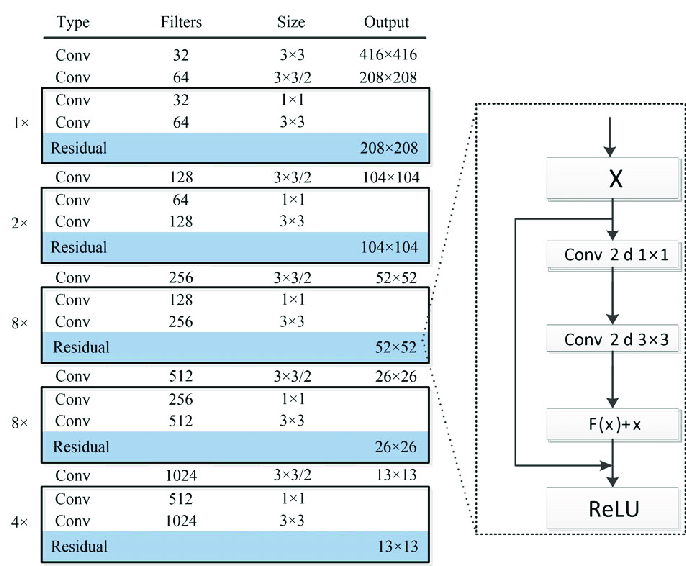

### Main implementation CPU: Forward

#### Back functions

Functions included:
- trunc(): truncate value into a certain range.
- conv2d_cpu(): 2d convolution on CPU.
- mean_cpu(): mean of 2d image on CPU.
- var_cpu(): variance of 2d image on CPU.
- bn_cpu(): batch normalization of 2d images in a 4d image block on CPU, uses mean_cpu() and var_cpu()
- leakyrelu_cpu(): LeakyReLU of 4d image block on CPU.
- conv_layer_cpu(): convolutional layer on CPU, uses conv2d_cpu(), bn_cpu(), leakyrelu_cpu().
- fixed_avg_pool_cpu(): average pooling of 2d images with fixed input sizes to 1x1, on CPU.
- linear_cpu(): linearly connected layer on CPU.
- softmax_cpu(): softmax on 1d array on CPU.
- crossentropy_cpu(): calculate cross-entropy between two arrays on CPU.

In [16]:
from numba import jit, prange
import math
import numpy as np

@jit
def trunc(val, min, max):
  if val < min:
    return min
  elif val > max:
    return max
  else:
    return val

@jit
def conv2d_cpu(input, kernel, bias, output, stride=1, padding=1, dilation=1):
  # calculate
  output_shape = (input.shape[0], kernel.shape[0],
                  math.floor((input.shape[2] - (kernel.shape[1] - 1) * dilation + 2*padding - 1) / stride) + 1,
                  math.floor((input.shape[3] - (kernel.shape[2] - 1) * dilation + 2*padding - 1) / stride) + 1)

  for im in range(output_shape[0]):
    for c_out in range(output_shape[1]):
      for x in range(output_shape[2]):
        for y in range(output_shape[3]):
          sum = 0
          for x_k in range(kernel.shape[1]):
            for y_k in range(kernel.shape[2]):
              x_in = x * stride + x_k * dilation - padding
              y_in = y * stride + y_k * dilation - padding
              x_in = trunc(x_in, 0, input.shape[2] - 1)
              y_in = trunc(y_in, 0, input.shape[3] - 1)

              sum += np.sum(input[im, :, x_in, y_in]) * kernel[c_out, x_k, y_k]
          output[im, c_out, x, y] = sum + bias[c_out]

@jit
def mean_cpu(image2d):
  sum = 0
  for y in range(image2d.shape[1]):
    for x in range(image2d.shape[0]):
      sum += image2d[x,y]
  return sum / image2d.shape[0] / image2d.shape[1]

@jit
def var_cpu(image2d):
  Mean = mean_cpu(image2d)
  L2sum = 0

  for y in range(image2d.shape[1]):
    for x in range(image2d.shape[0]):
      L2sum += (image2d[x,y] - Mean) ** 2
  return L2sum / image2d.shape[0] / image2d.shape[1]

@jit
def bn_cpu(image_tensor, stab=1e-5):
  channels = image_tensor.shape[1]
  for k in range(image_tensor.shape[0]):
    for c in range(image_tensor.shape[1]):
      Mean = mean_cpu(image_tensor[k,c])
      Var = var_cpu(image_tensor[k,c])

      image_tensor[k,c] = (image_tensor[k,c] - Mean) / np.sqrt(Var + stab)

@jit
def leakyrelu_cpu(image_arr, alpha=0.01):
  for i in range(image_arr.shape[0]):
    for j in range(image_arr.shape[1]):
      for k in range(image_arr.shape[2]):
        for l in range(image_arr.shape[3]):
          if image_arr[i,j,k,l] <= 0:
            image_arr[i,j,k,l] *= alpha

@jit
def conv_layer_cpu(image_arr, kernel, bias, output, stride=1, padding=0, dil=1):
  # convolution
  conv2d_cpu(input, kernel, bias, output, stride, padding, dilation)

  # batch norm
  bn_cpu(output)

  # leaky ReLU
  leakyrelu_cpu(output)

@jit
def global_avg_pool_cpu(input, output):
  for i in prange(input.shape[0]):
    for j in prange(input.shape[1]):
      output[i, j, 0, 0] = np.average(input[i, j])

@jit
def linear_cpu(input, weights, bias, output):
  # basically it's a multiplication of a matrix sized (N x W)
  # with weights (W x H), then for each sample, + bias (1 x H), to output (N x H)

  # weight: matmul
  for i in range(input.shape[0]):
    for j in range(weights.shape[1]):
      sum = 0
      for k in range(input.shape[1]):
        sum += input[i,k] * weights[k,j]
      output[i,j] = sum

  # bias: vector plus
  for i in range(input.shape[0]):
    output[i] += bias

@jit
def softmax_cpu(pred, output):
  for i in range(pred.shape[0]):
    sum = 0
    for j in range(pred.shape[1]):
      output[i,j] = np.exp(pred[i,j])
      sum += output[i,j]
    for j in range(pred.shape[1]):
      output[i,j] /= sum

@jit
def crossentropy_cpu(pred, truth, output, stab=1e-12):
  total_sum = 0
  n_samples, n_class = pred.shape
  for i in range(n_samples):
    sum = 0
    for j in range(n_class):
      pred_temp = pred[i,j] # to avoid affecting input
      if pred_temp == 0 or pred_temp == 1:
        pred_temp += stab
      sum += truth[i,j] * np.log(pred_temp)
    total_sum += -sum
  output[0] = total_sum / n_samples

In [17]:
%reload_ext autoreload
%autoreload 2

#### Layer classes

In [18]:
import math
import numpy as np

class CNNLayer:
  def __init__(self, in_channels):
    self.in_channels = in_channels

  def forward(self, input):
    if len(input.shape) != 4:
      raise ValueError(f"Input has to be a 4D array, got {len(input.shape)} instead.")
    elif input.shape[1] != self.in_channels:
      raise ValueError(f"Input has to have {self.in_channels} channels, got {input.shape[1]} instead.")

class Conv2DLayer(CNNLayer):
  def __init__(self, in_channels, out_channels, kernel_size, stride, padding, dilation):
    super().__init__(in_channels)
    self.out_channels = out_channels
    self.kernel_size = kernel_size
    self.stride = stride
    self.padding = padding
    self.dilation = dilation

    self.kernel = np.random.randn(out_channels, kernel_size, kernel_size)
    self.bias = np.random.randn(out_channels)

  def forward(self, input):
    # check
    super().forward(input)

    # setups
    nsamples, c_in, h_in, w_in = input.shape

    output_shape = (nsamples, self.out_channels,
                  math.floor((input.shape[2] - (self.kernel_size - 1) * self.dilation + 2*self.padding - 1) / self.stride) + 1,
                  math.floor((input.shape[3] - (self.kernel_size - 1) * self.dilation + 2*self.padding - 1) / self.stride) + 1)
    output = np.zeros(output_shape, dtype=np.float32)

    # execute
    conv2d_cpu(input, self.kernel, self.bias, output, self.stride, self.padding, self.dilation)
    bn_cpu(output)
    leakyrelu_cpu(output)

    return output

class ResidualBlock(CNNLayer):
  def __init__(self, in_channels):
    super().__init__(in_channels)
    self.mid_channels = in_channels // 2
    self.conv1 = Conv2DLayer(in_channels, self.mid_channels, 1, 1, 0, 1)
    self.conv2 = Conv2DLayer(self.mid_channels, self.in_channels, 3, 1, 1, 1)

  def forward(self, input):
    # check
    super().forward(input)

    # setups
    output1_shape = (input.shape[0], self.mid_channels, input.shape[2], input.shape[3])
    output1 = np.zeros(output1_shape, dtype=np.float32)
    output2 = np.zeros(input.shape, dtype=np.float32)

    # execute
    output1 = self.conv1.forward(input)
    bn_cpu(output1)
    output2 = self.conv2.forward(output1)
    bn_cpu(output2)
    output2 = output2 + input
    leakyrelu_cpu(output2)

    return output2

class GlobalAvgPool2D(CNNLayer): # currently this only pools to (1, 1)
  def __init__(self):
    pass

  def forward(self, input):
    # setups
    output_shape = list(input.shape)
    output_shape[-1], output_shape[-2] = 1, 1
    output = np.zeros(output_shape, dtype=np.float32)

    # execute
    global_avg_pool_cpu(input, output)

    return output

class Flatten2D(CNNLayer):
  def __init__(self):
    pass

  def forward(self, input): # too lazy!
    output_shape = (input.shape[0], np.prod(input.shape[1:]))
    return input.reshape(output_shape)

class Linear(CNNLayer):
  def __init__(self, in_features, out_features):
    self.in_features = in_features
    self.out_features = out_features
    self.weights = np.random.randn(in_features, out_features)
    self.bias = np.random.randn(out_features)

  def forward(self, input):
    # setups
    output = np.zeros((input.shape[0], self.out_features), dtype=np.float32)

    # execute
    linear_cpu(input, self.weights, self.bias, output)

    return output

class Softmax(CNNLayer):
  def __init__(self):
    pass

  def forward(self, input):
    # setups
    output = np.zeros(input.shape, dtype=np.float32)

    # execute
    softmax_cpu(input, output)

    return output

class LossFunction:
  def __init__(self):
    pass

  def forward(self, pred, truth):
    # check criteria
    if len(pred.shape) != 2:
      raise ValueError(f"Prediction has to be a 2D array (n_samples x n_class), got shape {pred.shape} instead.")
    if pred.shape != truth.shape:
      raise ValueError(f"Prediction and truth have to be the same length. Prediction: {pred.shape}, ground truth: {truth.shape}.")

class CrossEntropy(LossFunction):
  def __init__(self):
    pass


  def forward(self, pred, truth):
    # check criteria
    super().forward(pred, truth)

    # setups
    output = np.zeros(1, dtype=np.float32) # so it can be mutable, remember: GPU implementation does NOT have return

    # execute
    crossentropy_cpu(pred, truth, output)

    return output[0]

class CNN:
  def __init__(self, layers = None, lossfunc: LossFunction = CrossEntropy):
    if layers is None:
      self.layers = []
    elif isinstance(layers, CNNLayer):
      self.layers = [layers]
    elif isinstance(layers, list) and (len(layers) == 0 or isinstance(layers[0], CNNLayer)):
      self.layers = layers
    else:
      raise TypeError("Unsupported layer type")
    self.lossfunc = lossfunc

  def add(self, layer):
    if isinstance(layer, CNNLayer):
      self.layers.append(layer)
    elif isinstance(layer, list) and (len(layer) == 0 or isinstance(layer[0], CNNLayer)):
      self.layers.extend(layer)
    else:
      raise TypeError("Unsupported layer type")

  def forward(self, input):
    output = input
    for i in range(len(self.layers)):
      print(f"Layer {i}. ", end='')
      output = self.layers[i].forward(output)
      print(f"Output: {output.shape}")
    return output

  def loss(self, input):
    return self.lossfunc.criterion(input)

#### Test

In [19]:
if False:
  from classes import *
  # parameters
  n_samples, c_in, w_in, h_in, n_class = 5, 3, 32, 32, 10
  input = np.random.randn(n_samples, c_in, w_in, h_in)
  truth = np.random.rand(n_samples, n_class)
  for i in range(n_samples):
    truth[i] /= np.sum(truth[i]) # normalize

  # model & loss
  darknet53 = CNN([
      Conv2DLayer(3, 32, 3, 1, 1, 1),
      Conv2DLayer(32, 64, 3, 2, 1, 1),
      ResidualBlock(64),
      Conv2DLayer(64, 128, 3, 2, 1, 1),
      ResidualBlock(128),
      ResidualBlock(128),
      Conv2DLayer(128, 256, 3, 2, 1, 1),
      ResidualBlock(256),
      ResidualBlock(256),
      ResidualBlock(256),
      ResidualBlock(256),
      ResidualBlock(256),
      ResidualBlock(256),
      ResidualBlock(256),
      ResidualBlock(256),
      Conv2DLayer(256, 512, 3, 2, 1, 1),
      ResidualBlock(512),
      ResidualBlock(512),
      ResidualBlock(512),
      ResidualBlock(512),
      ResidualBlock(512),
      ResidualBlock(512),
      ResidualBlock(512),
      ResidualBlock(512),
      Conv2DLayer(512, 1024, 3, 2, 1, 1),
      ResidualBlock(1024),
      ResidualBlock(1024),
      ResidualBlock(1024),
      ResidualBlock(1024),
      GlobalAvgPool2D(),
      Flatten2D(),
      Linear(1024, 10),
      Softmax()
  ])
  criterion = CrossEntropy()

  # execute
  output = darknet53.forward(input)
  print(output.shape)
  loss = criterion.forward(output, truth)
  print(loss)

### Main implementation CPU: Backward

The layers in the backward order is:
- Loss: cross-entropy.
- Softmax.
- Linear.
- Flatten.
- Pooling.
- Convolution.

Our optimizer used is going to be Adam, which is a popular choice.

#### Step-by-step

##### Adam optimizer

Main reference: https://www.geeksforgeeks.org/deep-learning/adam-optimizer/

So there are 4 steps about the Adam optimizer.
1. Calculate weight gradient from loss.\
$g_t = \frac{\partial L}{\partial w_t}$
2. Update 2 moments.\
$m_t = \beta_1 m_{t-1} + (1 - \beta_1) g_t$\
$v_t = \beta_2 v_{t-1} + (1 - \beta_2) g_t^2$
3. Bias correction.\
$\hat{m}_t = \frac{m_t}{1 - \beta_1^t}$\
$\hat{v}_t = \frac{v_t}{1 - \beta_2^t}$
4. Update the parameters.\
$\theta_t = \theta_{t-1} - \alpha \cdot \frac{\hat{m}_t}{\sqrt{\hat{v}_t} + \epsilon}$

Where we have the static parameters:
- $\alpha$: learning rate \\
- $\beta_1$: decay rate for first moment estimate \\
- $\beta_2$: decay rate for second moment estimate \\
- $\epsilon$: small constant for numerical stability

where the 2 moment parameters $m_t$ and $v_t$ are separate for each layer of the CNN, weight and bias each has two moments of their own, so we have 4 moment parameters in total.

##### Loss function: Cross-entropy

## CPU Implementation: CSP-enhanced Darknet53
Progress: forward (100%).

The general idea of cross stage partial (CSP) in Darknet, is alternating the residual block so that: the input is alongside the dimension channel (should be even) by half, where one is put through the residual block, and the other is passed completely unchanged; then we concatenate the halves in some way.

There are multiple variants of how to apply CSP, revolving around 1x1 convolution layer being applied between each part to boost performance and to shuffle the features, but here we just apply it once: after the concatenation.

So we alter the ResidualBlock to CSPResBlock.

In [20]:
%%writefile -a classes.py

class CSPResBlock(ResidualBlock):
  def __init__(self, in_channels):
    # check
    if in_channels % 4 != 0:
      raise ValueError("Input channels must be divisible by 4")
    super().__init__(in_channels)

    # para
    split_channels = in_channels // 2
    self.conv1 = Conv2DLayer(split_channels, split_channels // 2, 1, 1, 0, 1)
    self.conv2 = Conv2DLayer(split_channels // 2, split_channels, 3, 1, 1, 1)
    self.conv3 = Conv2DLayer(in_channels, in_channels, 1, 1, 0, 1)

  def forward(self, input):
    # check
    super().forward(input)

    # execute
    input1, input2 = np.split(input, 2, axis=1)
    input1 = self.conv1.forward(input1)
    input1 = self.conv2.forward(input1)
    output = np.concatenate([input1, input2], axis=1)
    output = self.conv3.forward(output)
    return output

Appending to classes.py


# Spatial Pyramid Pooling (SPP)
Progress: forward (100%).

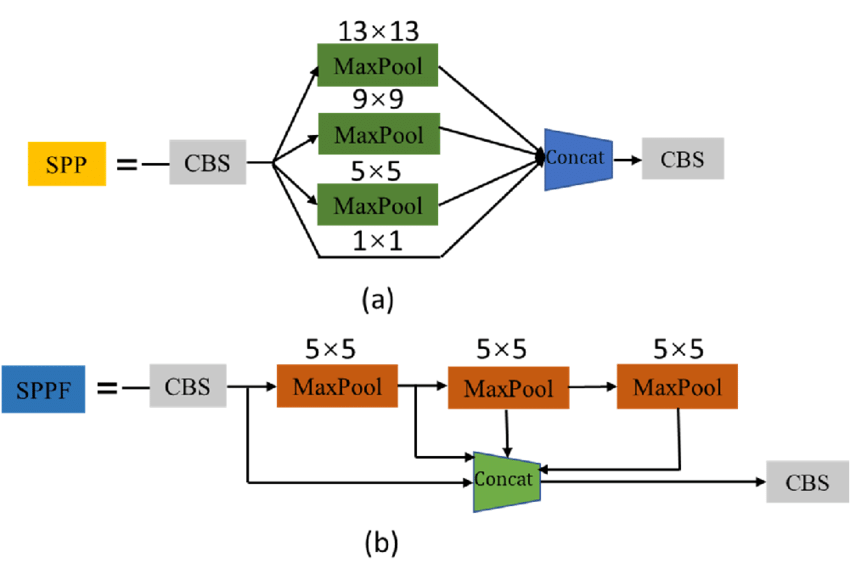

SPP is basically passing the input through 3 channels of MaxPooling and concatenated with the original input, similar to skip-connection. A 1x1 convolution layer is usually applied after the concatenation to shuffle the parameters and boost the performances.

In [31]:
def local_max_pooling2D(input, output, kernel_size, stride, padding, dilation):
  for i in range(output.shape[0]):
    for j in range(output.shape[1]):
      for k in range(output.shape[2]):
        for l in range(output.shape[3]):
          max_val = -np.inf
          for x_k in range(kernel_size):
            for y_k in range(kernel_size):
              x_i = trunc(k * stride + x_k * dilation - padding, 0, output.shape[2] - 1)
              y_i = trunc(l * stride + y_k * dilation - padding, 0, output.shape[3] - 1)
              max_val = max(max_val, output[i, j, x_i, y_i])
          output[i, j, k, l] = max_val

class LocalMaxPooling2D(CNNLayer):
  def __init__(self, kernel_size):
    self.kernel_size = kernel_size
    self.stride = 1
    self.padding = (kernel_size - 1) // 2
    self.dilation = 1

  def forward(self, input):
    output_size = input.shape
    output = np.zeros(output_size, dtype = input.dtype)
    local_max_pooling2D(input, output, self.kernel_size, self.stride, self.padding, self.dilation)
    return output

class SPP(CNNLayer):
  def __init__(self, in_channels):
    super().__init__(in_channels)

  def forward(self, input):
    # check
    super().forward(input)

    # execute
    maxpool5 = LocalMaxPooling2D(5)
    maxpool9 = LocalMaxPooling2D(9)
    maxpool13 = LocalMaxPooling2D(13)

    output1 = maxpool5.forward(input)
    output2 = maxpool9.forward(input)
    output3 = maxpool13.forward(input)

    output = np.concatenate((input, output1, output2, output3), axis = 1)
    conv = Conv2DLayer(self.in_channels * 4, self.in_channels * 4, 1, 1, 0, 1)
    output = conv.forward(output)

    return output

# Path Aggregation Network (PAN)
Progress: none.